In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
X_df = pd.read_pickle('X_df.pkl')
X_df

,0.5 yr,1 yr,2 yr,5 yr,7 yr,10 yr,20 yr,30 yr
DATE,,,,,,,,
2022-01-04,0.000000,-0.050000,-0.012821,0.000000,0.012903,0.018405,0.024390,0.029851
2022-01-05,0.000000,0.078947,0.077922,0.043796,0.031847,0.030120,0.009524,0.009662
2022-01-06,0.045455,0.097561,0.060241,0.027972,0.024691,0.011696,0.000000,0.000000
2022-01-07,0.043478,-0.044444,-0.011364,0.020408,0.018072,0.017341,0.014151,0.009569
2022-01-10,0.166667,0.069767,0.057471,0.020000,0.011834,0.011364,0.000000,0.000000
...,...,...,...,...,...,...,...,...
2022-12-23,0.002146,0.004310,0.016509,0.018470,0.015915,0.021798,0.020460,0.024129
2022-12-27,0.019272,0.019313,0.002320,0.020725,0.026110,0.024000,0.027569,0.028796
2022-12-28,-0.002101,-0.008421,-0.002315,0.007614,0.010178,0.010417,0.007317,0.012723


In [7]:
len(X_df)

248

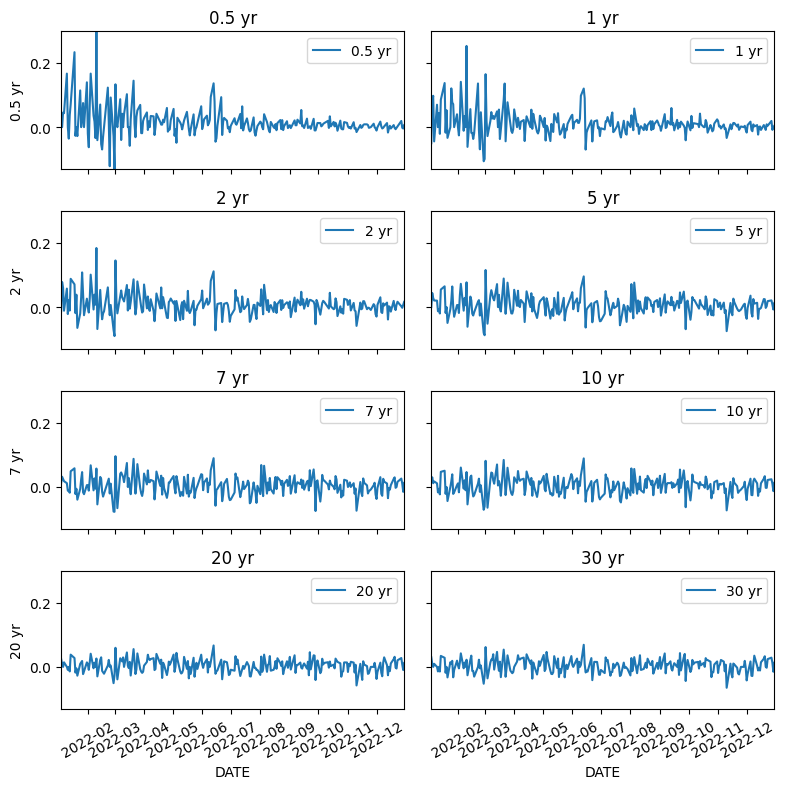

In [11]:
#获取整个X_df的最大值和最小值,统一y轴范围
#第一次提出每一行的最大值最小值,第二次根据上一次的提取出的最大值最小值就是针对全部的
y_min = X_df.min().min()
y_max = X_df.max().max()

fig,axes = plt.subplots(4,2,figsize = (8,8),sharex = True,sharey = True)
axes = axes.flatten()

for i,col in enumerate(X_df.columns):
    sns.lineplot(data = X_df[col],
                 markers = False,
                 dashes = False,#不需要虚线
                 ax = axes[i])
    axes[i].set_title(col)
    #参数:  图例名称为本列名 图例放置在右上角 图例拍成一列(参数为配置几列)
    axes[i].legend([col],loc = 'upper right',ncol = 1)
    axes[i].set_ylim(y_min,y_max)
    axes[i].set_xlim(X_df.index[0],X_df.index[-1])
    axes[i].tick_params(axis = 'x',rotation = 30)

plt.tight_layout()

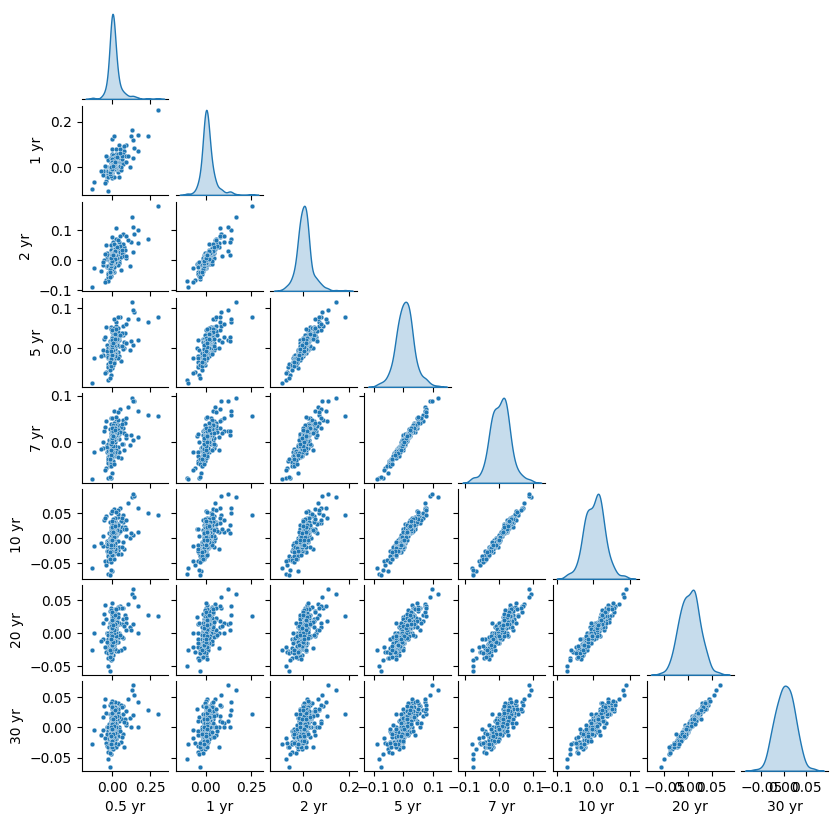

In [13]:
#corner表示角,只绘制下三角 用核密度估计曲线图 给散点图的参数字典告诉size为12
g = sns.pairplot(X_df,corner = True,diag_kind = 'kde',plot_kws = {'s':12})
#配置英寸的大小
g.fig.set_size_inches(8,8)

In [15]:
#中心化

In [17]:
#默认按照列求均值
mean = X_df.mean()
mean = np.array(mean).reshape(-1,1)
mean

array([[0.01336972],
       [0.01074155],
       [0.00756404],
       [0.00477784],
       [0.00421179],
       [0.00387352],
       [0.00305352],
       [0.00297673]])

In [19]:
X_df_c = X_df - X_df.mean()

In [21]:
#协方差矩阵

In [23]:
cov = X_df.cov()

<Axes: >

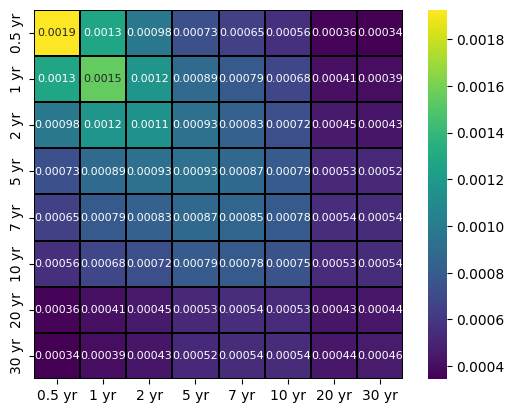

In [25]:
fig,ax = plt.subplots()
sns.heatmap(cov,ax = ax,
            annot = True,
            annot_kws = {'size':8},
            linecolor = 'k',linewidth = '0.1',
            cmap = 'viridis',
            square = True)

In [27]:
#标准差

In [29]:
D_sq = np.sqrt(np.diag(cov))
D_sq

array([0.04388477, 0.03930359, 0.03382721, 0.03043679, 0.02918109,
       0.02732218, 0.02083015, 0.02144493])

In [31]:
D_sq_df = X_df.std()
D_sq_df

0.5 yr    0.043885
1 yr      0.039304
2 yr      0.033827
5 yr      0.030437
7 yr      0.029181
10 yr     0.027322
20 yr     0.020830
30 yr     0.021445
dtype: float64

(0.02, 0.045)

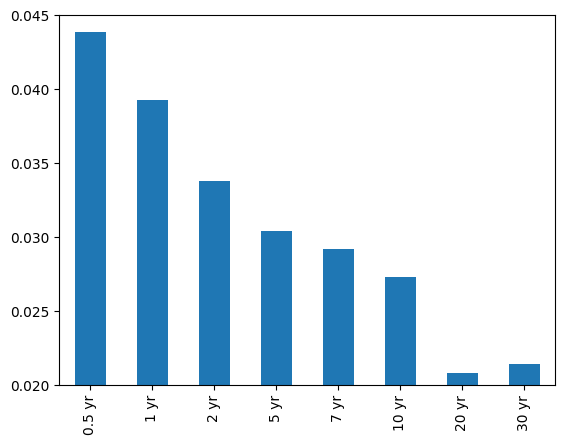

In [33]:
D_sq_df.plot(kind = 'bar') #kind表示图例类型,这里用柱状图
plt.ylim(0.02,0.045)

In [35]:
D = np.diag(D_sq)
D

array([[0.04388477, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.03930359, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.03382721, 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.03043679, 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.02918109,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.02732218, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.02083015, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.02144493]])

In [37]:
#标准化

In [39]:
Z_df = (X_df - X_df.mean())@np.linalg.inv(D)
Z_df.columns = X_df.columns
Z_df

,0.5 yr,1 yr,2 yr,5 yr,7 yr,10 yr,20 yr,30 yr
DATE,,,,,,,,
2022-01-04,-0.304655,-1.545445,-0.602608,-0.156976,0.297845,0.531853,1.024319,1.253164
2022-01-05,-0.304655,1.735359,2.079924,1.281928,0.947029,0.960647,0.310621,0.311733
2022-01-06,0.731115,2.208944,1.557235,0.762044,0.701810,0.286302,-0.146591,-0.138808
2022-01-07,0.686082,-1.404096,-0.559540,0.513534,0.474982,0.492915,0.532758,0.307422
2022-01-10,3.493170,1.501794,1.475357,0.500124,0.261215,0.274141,-0.146591,-0.138808
...,...,...,...,...,...,...,...,...
2022-12-23,-0.255756,-0.163629,0.264444,0.449844,0.401059,0.656055,0.835656,0.986338
2022-12-27,0.134494,0.218091,-0.155019,0.523956,0.750413,0.736635,1.176919,1.203971
2022-12-28,-0.352527,-0.487554,-0.292039,0.093189,0.204459,0.239481,0.204682,0.454462


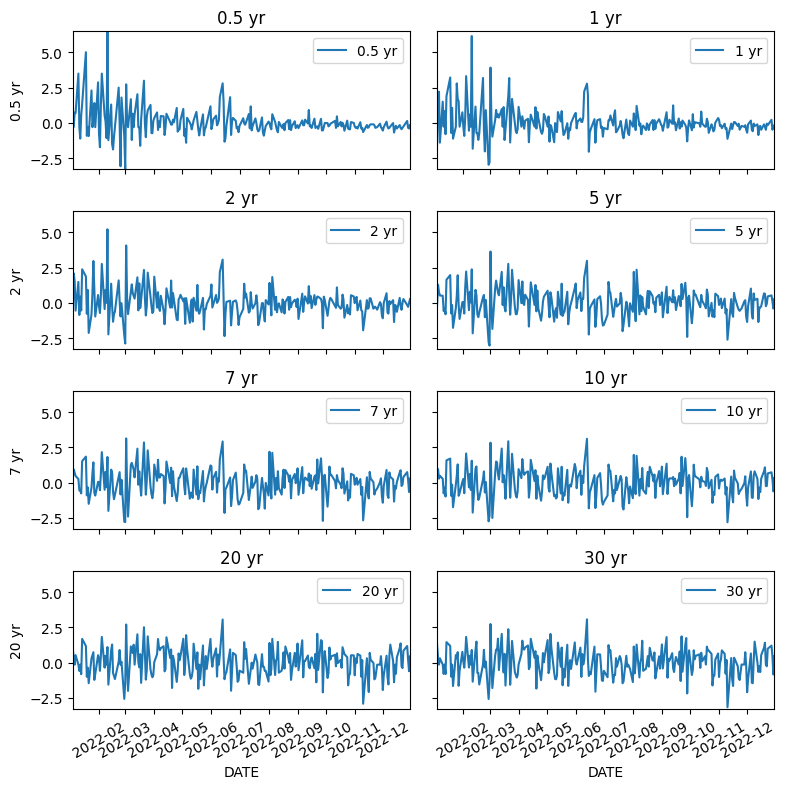

In [41]:
y_min = Z_df.min().min()
y_max = Z_df.max().max()

fig,axes = plt.subplots(4,2,figsize = (8,8),sharex = True,sharey = True)
axes = axes.flatten()

for i,col in enumerate(Z_df.columns):
    sns.lineplot(data = Z_df[col],
                 markers = False,
                 dashes = False,
                 ax = axes[i])
    axes[i].set_title(col)
    axes[i].legend([col],loc = 'upper right',ncol = 1)
    axes[i].set_ylim(y_min,y_max)
    axes[i].set_xlim(Z_df.index[0],Z_df.index[-1])
    axes[i].tick_params(axis = 'x',rotation = 30)
#调整布局防止重叠
plt.tight_layout()

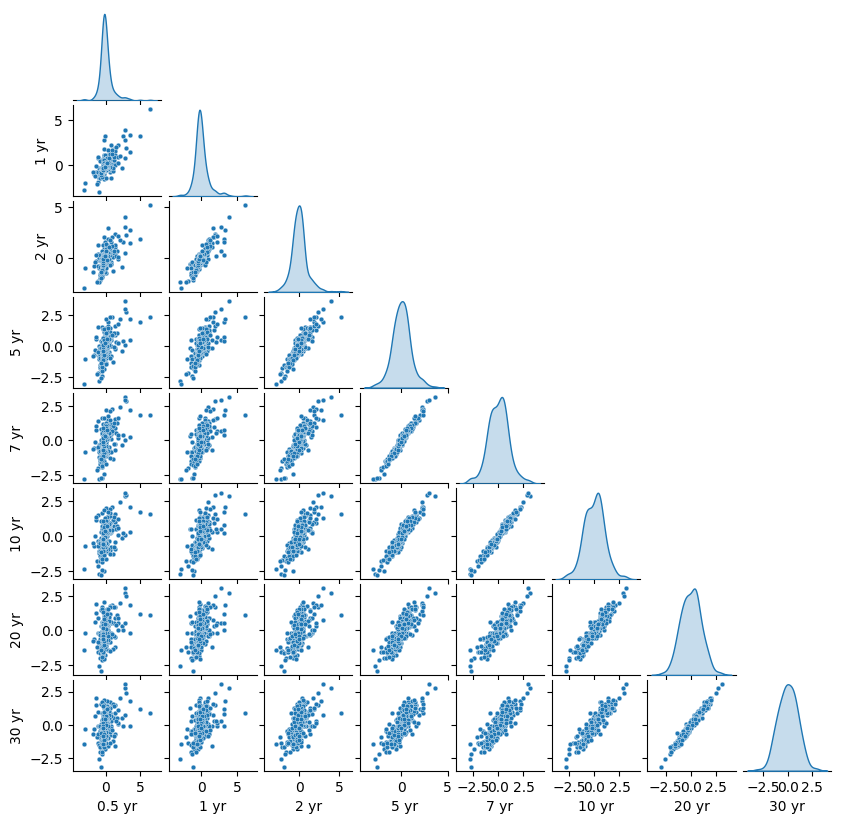

In [43]:
g = sns.pairplot(Z_df,corner = True,diag_kind = 'kde',plot_kws = {'s':12})
g.fig.set_size_inches(8,8)

In [44]:
#线性相关系数矩阵

In [47]:
P = X_df.corr()
P

,0.5 yr,1 yr,2 yr,5 yr,7 yr,10 yr,20 yr,30 yr
0.5 yr,1.000000,0.741326,0.658817,0.547214,0.508018,0.469002,0.395009,0.365413
1 yr,0.741326,1.000000,0.877098,0.741927,0.685748,0.633442,0.497752,0.466968
2 yr,0.658817,0.877098,1.000000,0.899742,0.838473,0.782254,0.637459,0.593849
5 yr,0.547214,0.741927,0.899742,1.000000,0.982671,0.951628,0.833816,0.793134
7 yr,0.508018,0.685748,0.838473,0.982671,1.000000,0.983504,0.894960,0.857845
10 yr,0.469002,0.633442,0.782254,0.951628,0.983504,1.000000,0.939536,0.915748
20 yr,0.395009,0.497752,0.637459,0.833816,0.894960,0.939536,1.000000,0.981736
30 yr,0.365413,0.466968,0.593849,0.793134,0.857845,0.915748,0.981736,1.000000


In [49]:
n = len(Z_df)
Z_df.T@Z_df/(n-1)
#检验

,0.5 yr,1 yr,2 yr,5 yr,7 yr,10 yr,20 yr,30 yr
0.5 yr,1.000000,0.741326,0.658817,0.547214,0.508018,0.469002,0.395009,0.365413
1 yr,0.741326,1.000000,0.877098,0.741927,0.685748,0.633442,0.497752,0.466968
2 yr,0.658817,0.877098,1.000000,0.899742,0.838473,0.782254,0.637459,0.593849
5 yr,0.547214,0.741927,0.899742,1.000000,0.982671,0.951628,0.833816,0.793134
7 yr,0.508018,0.685748,0.838473,0.982671,1.000000,0.983504,0.894960,0.857845
10 yr,0.469002,0.633442,0.782254,0.951628,0.983504,1.000000,0.939536,0.915748
20 yr,0.395009,0.497752,0.637459,0.833816,0.894960,0.939536,1.000000,0.981736
30 yr,0.365413,0.466968,0.593849,0.793134,0.857845,0.915748,0.981736,1.000000


<Axes: >

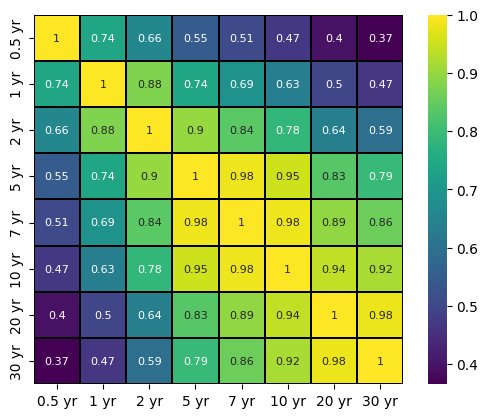

In [51]:
fig,ax = plt.subplots()
sns.heatmap(P,ax = ax,
            annot = True,annot_kws = {'size':8},
            linecolor = 'k',linewidths = '0.1',
            cmap = 'viridis',
            square = True)

In [53]:
#特征值分解

In [59]:
lambdas,V = np.linalg.eig(P)
#按照特征值从大到小排序,返回索引值
#-对lambdas取反,然后按照默认的升序排列(从小到大),因为有负号(最大值变为最小值)最后变成了降序
#最后取出按照lambdas的从大到小的值
idx = np.argsort(-lambdas)

#idx是数组索引,取出后将每个元素自动组合
lambdas_sorted = lambdas[idx]
V = V[:,idx]
Lambda = np.diag(lambdas_sorted)

<Axes: >

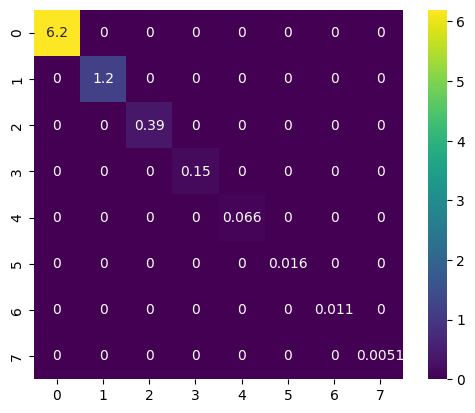

In [61]:
fig,ax = plt.subplots()
sns.heatmap(Lambda,ax = ax,
            annot = True,
            cmap = 'viridis',
            square = True)

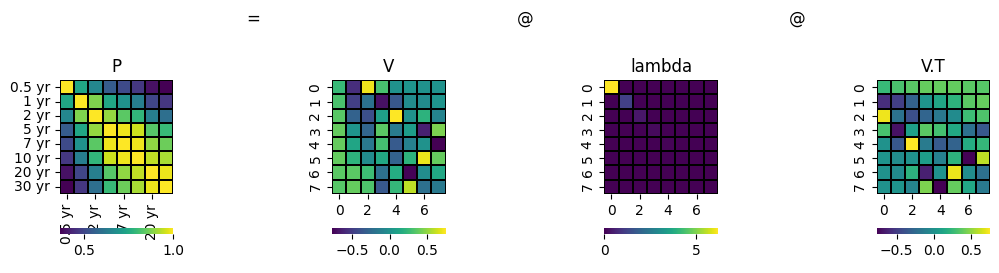

In [91]:
fig,axs = plt.subplots(1,7,figsize = (12,3))
plt.sca(axs[0])
ax = sns.heatmap(P,cmap = 'viridis',
                 linecolor = 'k',linewidths = 0.1,
                 cbar_kws = {'orientation':'horizontal'})
ax.set_aspect('equal')
plt.title('P')

plt.sca(axs[1])
plt.title('=')
plt.axis('off')

plt.sca(axs[2])
ax = sns.heatmap(V,cmap = 'viridis',
                 linecolor = 'k',linewidth = 0.1,
                 cbar_kws = {'orientation':'horizontal'})
ax.set_aspect('equal')
plt.title('V')

plt.sca(axs[3])
plt.title('@')
plt.axis('off')

plt.sca(axs[4])
ax = sns.heatmap(Lambda,cmap = 'viridis',
                 linecolor = 'k',linewidth = 0.1,
                 cbar_kws = {'orientation':'horizontal'})
ax.set_aspect('equal')
plt.title('lambda')

plt.sca(axs[5])
plt.title('@')
plt.axis('off')

plt.sca(axs[6])
ax = sns.heatmap(V.T,cmap = 'viridis',
                 linecolor = 'k',linewidth = 0.1,
                 cbar_kws = {'orientation':'horizontal'})
ax.set_aspect('equal')
plt.title('V.T')
plt.savefig('4.svg')

In [93]:
lambdas_sorted

array([6.19819963e+00, 1.16487298e+00, 3.86438666e-01, 1.53121560e-01,
       6.55072070e-02, 1.55648171e-02, 1.11641690e-02, 5.13097110e-03])

In [101]:
Y = Z_df @ V

Text(0.5, 1.0, '@V')

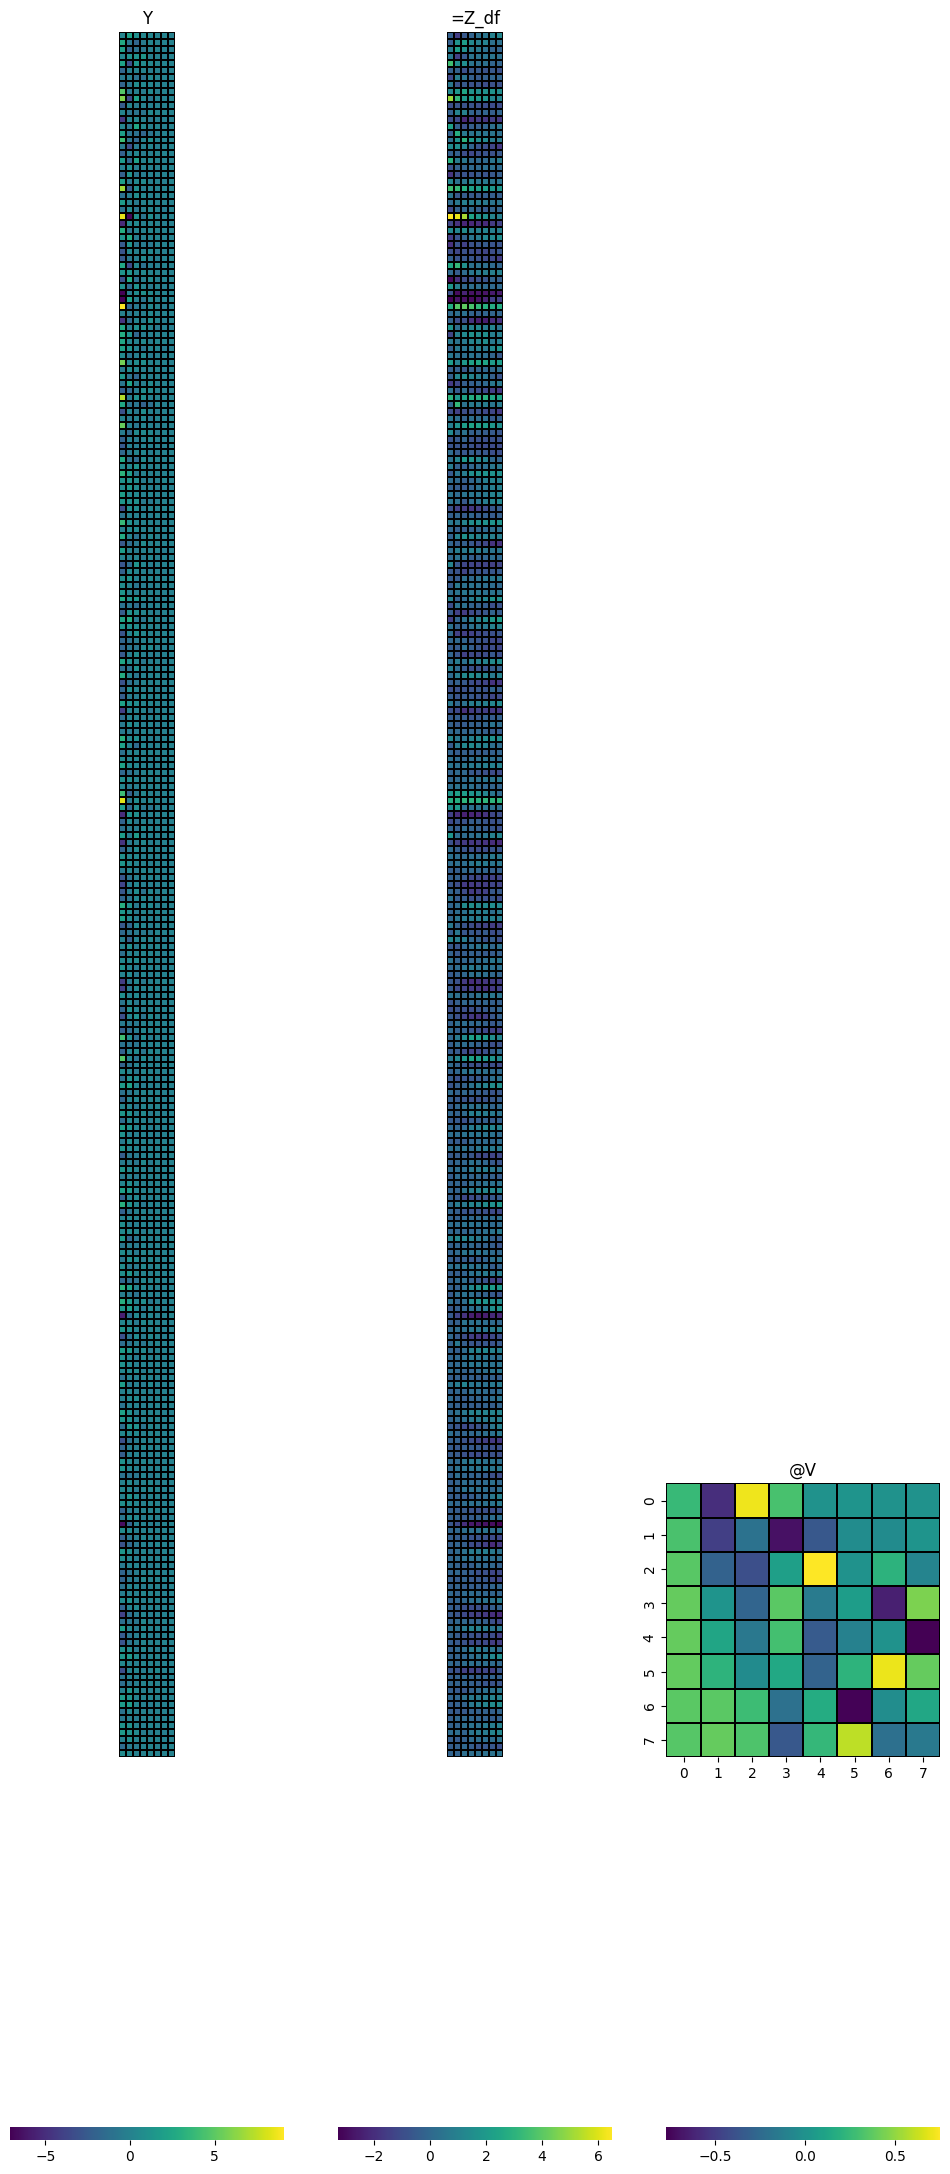

In [119]:
fig,axs = plt.subplots(1,3,figsize = (12,32))
plt.sca(axs[0])
ax = sns.heatmap(Y,cmap = 'viridis',
                 linecolor = 'k',linewidths = 0.1,
                 cbar_kws = {'orientation':'horizontal'})
ax.set_aspect('equal')
plt.axis('off')
plt.title('Y')

plt.sca(axs[1])
ax = sns.heatmap(Z_df,cmap = 'viridis',
                 linecolor = 'k',linewidth = 0.1,
                 cbar_kws = {'orientation':'horizontal'})
ax.set_aspect('equal')
plt.axis('off')
plt.title('=Z_df')

plt.sca(axs[2])
ax = sns.heatmap(V,cmap = 'viridis',
                 linecolor = 'k',linewidth = 0.1,
                 cbar_kws = {'orientation':'horizontal'})
ax.set_aspect('equal')
plt.title('@V')

In [121]:
Lambdas_Y = V.T @ P @ V

Text(0.5, 1.0, 'V')

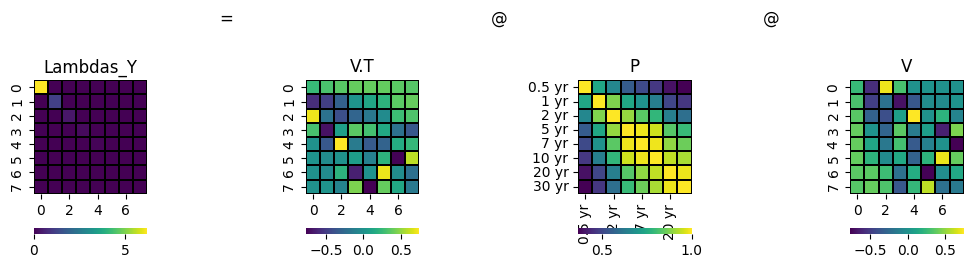

In [123]:
fig,axs = plt.subplots(1,7,figsize = (12,3))
plt.sca(axs[0])
ax = sns.heatmap(Lambdas_Y,cmap = 'viridis',
                 linecolor = 'k',linewidths = 0.1,
                 cbar_kws = {'orientation':'horizontal'})
ax.set_aspect('equal')
plt.title('Lambdas_Y')

plt.sca(axs[1])
plt.title('=')
plt.axis('off')

plt.sca(axs[2])
ax = sns.heatmap(V.T,cmap = 'viridis',
                 linecolor = 'k',linewidth = 0.1,
                 cbar_kws = {'orientation':'horizontal'})
ax.set_aspect('equal')
plt.title('V.T')

plt.sca(axs[3])
plt.title('@')
plt.axis('off')

plt.sca(axs[4])
ax = sns.heatmap(P,cmap = 'viridis',
                 linecolor = 'k',linewidth = 0.1,
                 cbar_kws = {'orientation':'horizontal'})
ax.set_aspect('equal')
plt.title('P')

plt.sca(axs[5])
plt.title('@')
plt.axis('off')

plt.sca(axs[6])
ax = sns.heatmap(V,cmap = 'viridis',
                 linecolor = 'k',linewidth = 0.1,
                 cbar_kws = {'orientation':'horizontal'})
ax.set_aspect('equal')
plt.title('V')

In [125]:
#方差解释比例

In [127]:
variance_V = lambdas_sorted
variance_V

array([6.19819963e+00, 1.16487298e+00, 3.86438666e-01, 1.53121560e-01,
       6.55072070e-02, 1.55648171e-02, 1.11641690e-02, 5.13097110e-03])

In [129]:
#计算每一个比例
explained_var_ratio = variance_V/variance_V.sum()

In [135]:
PC_range = np.arange(len(variance_V))+1

In [141]:
labels = ['$PC_' + str(index) + '$' for index in PC_range]

(0.9, 8.1)

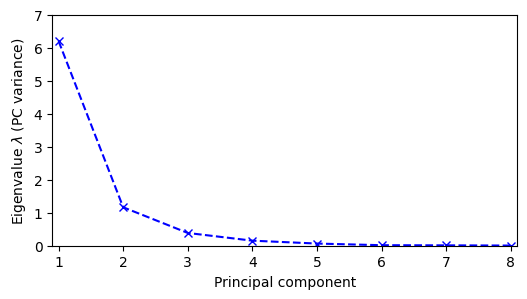

In [151]:
fig,ax = plt.subplots(figsize = (6,3))

ax.plot(PC_range,variance_V,'b',marker = 'x',linestyle = '--')
ax.set_xlabel(r'Principal component')
ax.set_ylabel(r'Eigenvalue $\lambda$ (PC variance)')
ax.set_ylim(0,7);ax.set_xticks(PC_range)
ax.set_xlim(PC_range.min() - 0.1,PC_range.max() +0.1)

Text(0.5, 0, 'Principal component')

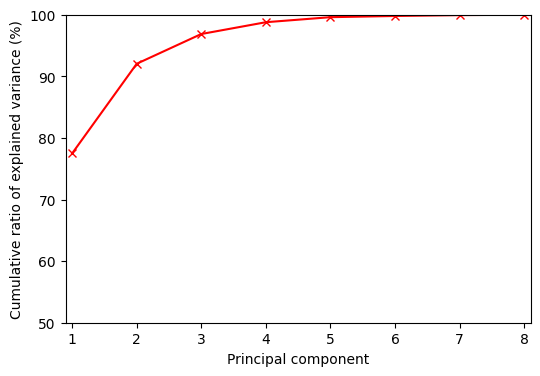

In [159]:
fig,ax = plt.subplots(figsize = (6,4))
#cumsum是累加操作,每个值的位置的值是传入列表中的对应位置的值加上前面的所有的值
ax.plot(PC_range,np.cumsum(explained_var_ratio)*100,
        'r',marker = 'x')
ax.set_ylabel('Cumulative ratio of explained variance (%)')
ax.set_ylim(50,100)
ax.set_xlim(PC_range.min() - 0.1,PC_range.max() + 0.1)
ax.set_xlabel('Principal component')

In [161]:
#还原原始数据

In [163]:
num_p = 1
loadings = V[:,0:num_p]
Z_df_hat = Y.iloc[:,:num_p] @ loadings.T
X_df_hat = Z_df_hat @ D + mean.T
X_df_hat.columns = X_df.columns
X_df_hat

,0.5 yr,1 yr,2 yr,5 yr,7 yr,10 yr,20 yr,30 yr
DATE,,,,,,,,
2022-01-04,0.016529,0.014238,0.010967,0.008106,0.007412,0.006842,0.005153,0.005068
2022-01-05,0.043557,0.044156,0.040084,0.036585,0.034795,0.032239,0.023118,0.022958
2022-01-06,0.036213,0.036027,0.032172,0.028846,0.027354,0.025338,0.018237,0.018097
2022-01-07,0.017933,0.015793,0.012480,0.009586,0.008835,0.008162,0.006087,0.005997
2022-01-10,0.038196,0.038222,0.034309,0.030936,0.029363,0.027201,0.019555,0.019410
...,...,...,...,...,...,...,...,...
2022-12-23,0.026961,0.025786,0.022206,0.019098,0.017981,0.016645,0.012087,0.011973
2022-12-27,0.032207,0.031593,0.027857,0.024625,0.023296,0.021574,0.015574,0.015445
2022-12-28,0.014391,0.011872,0.008665,0.005854,0.005247,0.004833,0.003733,0.003653


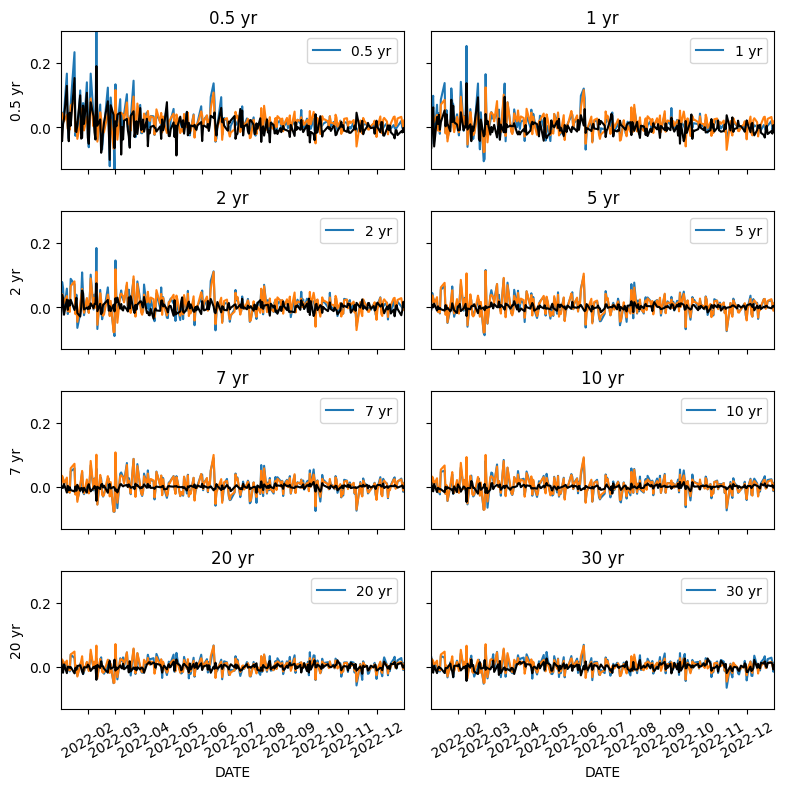

In [179]:
#比较原始数据和还原数据
y_min = X_df.min().min()
y_max = X_df.max().max()

fig,axes = plt.subplots(4,2,figsize = (8,8),sharex = True,sharey = True)
axes = axes.flatten()

for i,col in enumerate(X_df.columns):
    #原数据
    sns.lineplot(data = X_df[col],
                 markers = False,
                 dashes = False,
                 ax = axes[i])

    #近似数据
    sns.lineplot(data = X_df_hat[col],
                markers = False,
                dashes = False,
                ax = axes[i])
    #误差
    sns.lineplot(X_df[col] - X_df_hat[col],c = 'k',ax = axes[i])

    axes[i].set_title(col)
    axes[i].legend([col],loc = 'upper right',ncol = 1)
    axes[i].set_ylim(y_min,y_max)
    axes[i].set_xlim(X_df_hat.index[0],X_df_hat.index[-1])
    axes[i].tick_params(axis = 'x',rotation = 30)

plt.tight_layout()

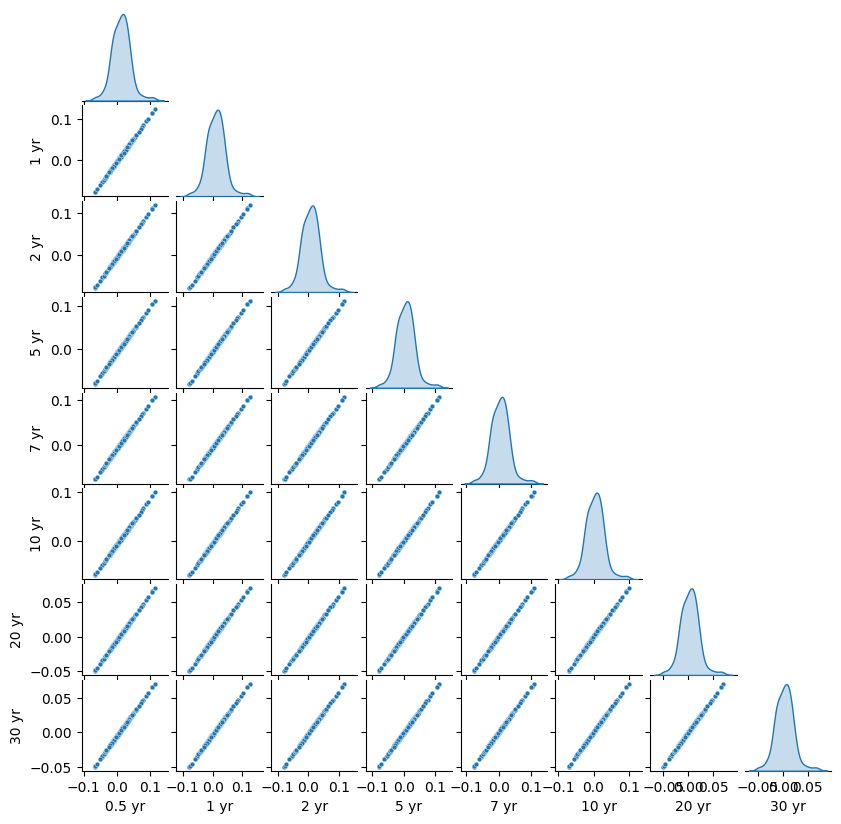

In [181]:
g = sns.pairplot(X_df_hat,corner = True,diag_kind = 'kde',plot_kws = {'s':12})
g.fig.set_size_inches(8,8)

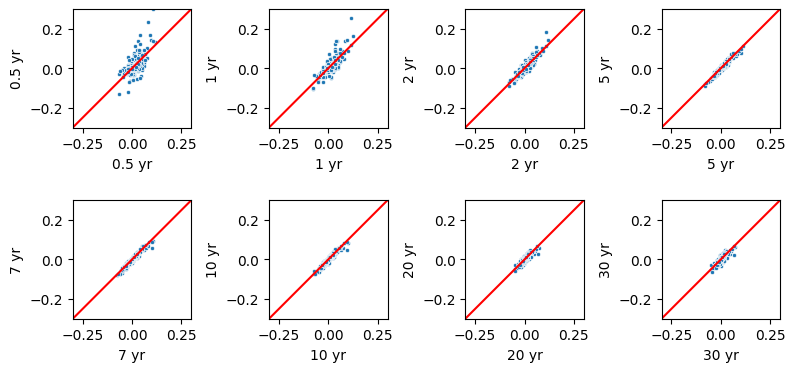

In [189]:
#散点图
fig,axes = plt.subplots(2,4,figsize = (8,4))
axes = axes.flatten()

#zip将两个可迭代对象按照顺序组成元组,按照zip中的参数对应位置组成
#[1,2,3] , [a,b,c]  >>> [(1,a),(2,b),(3,c)]
#如果包中元素与变量名数量对应,for会自动拆包,将可迭代对象中的每个元素拆开依次赋值给循环中的变量
    #这仅仅发生在单层嵌套
    #多层嵌套使用特殊对应的传入可迭代数组所用的形状,或者使用多层for循环
for col_idx,ax_idx in zip(list(X_df_hat.columns),axes):
    sns.scatterplot(x = X_df_hat[col_idx],
                    y = X_df[col_idx],
                    marker = '.',
                    ax = ax_idx)
    ax_idx.plot([-0.3,0.3],[-0.3,0.3],c = 'r')
    ax_idx.set_aspect('equal',adjustable = 'box')
    ax_idx.set_xlim(-0.3,0.3);ax_idx.set_ylim(-0.3,0.3)

plt.tight_layout()

In [191]:
V

array([[ 0.2566362 , -0.57050021,  0.71567785,  0.30986556,  0.0033094 ,
         0.02031601,  0.00494206,  0.00279441],
       [ 0.31718202, -0.48850068, -0.19730075, -0.69950702, -0.35903844,
        -0.03840762, -0.04299898,  0.01709801],
       [ 0.35866489, -0.29473202, -0.40355095,  0.08138629,  0.7516045 ,
         0.0057255 ,  0.20812967, -0.08219103],
       [ 0.3898738 ,  0.01894657, -0.28025059,  0.36217845, -0.14264308,
         0.07149901, -0.63779654,  0.45352204],
       [ 0.39100012,  0.12559201, -0.1604778 ,  0.29559277, -0.33817791,
        -0.10608886, -0.00253392, -0.76979983],
       [ 0.38732446,  0.21507179, -0.03942454,  0.14068669, -0.29158832,
         0.21151225,  0.70709571,  0.39068059],
       [ 0.3593704 ,  0.36335743,  0.27058727, -0.20642827,  0.16791945,
        -0.7583426 , -0.03081063,  0.13698344],
       [ 0.34762469,  0.39320836,  0.32704583, -0.35650505,  0.24132776,
         0.60157414, -0.21698897, -0.15256043]])

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.multivariate.pca as pca

In [195]:
X_df = pd.read_pickle('X_df.pkl')

In [197]:
P = X_df.corr()

In [201]:
pca_model = pca.PCA(X_df,standardize = True) #参数表示是否进行标准化处理

In [203]:
variance_V = pca_model.eigenvals #特征值就是标准化后的矩阵向v投影的方差

In [205]:
explained_var_ratio = variance_V / variance_V.sum()

In [207]:
PC_range = np.arange(len(variance_V)) + 1

In [209]:
labels = ['$PC_' + str(index) + '$' for index in PC_range]

(0.9, 8.1)

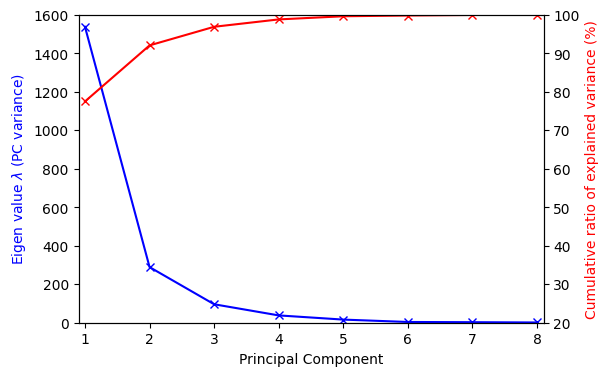

In [229]:
fig,ax1 = plt.subplots(figsize = (6,4))

ax1.plot(PC_range,variance_V,'b',marker = 'x')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel(r'Eigen value $\lambda$ (PC variance)',color = 'b')
ax1.set_ylim(0,1600);ax1.set_xticks(PC_range)

#创建共享x轴但是有独立y轴的新坐标轴 twin表示成对坐标轴(xy)  x表示共享的轴  自然多出来一个y
#ax1绘图轴可以存储多个轴 默认只有xy轴 这个函数新添加了一个y轴在其中,但是数据最后还是在ax1上绘制
#ax2接收到的还是ax1上的共享x和ax1中添加的y 还是属于ax1的空间,修改ax1绘图轴数据
ax2 = ax1.twinx()
ax2.plot(PC_range,np.cumsum(explained_var_ratio)*100,
         'r',marker = 'x')
ax2.set_ylabel(r'Cumulative ratio of explained variance (%)',
               color = 'r')
ax2.set_ylim(20,100)
ax2.set_xlim(PC_range.min() - 0.1,PC_range.max() + 0.1)

In [231]:
loadings = pca_model.loadings[['comp_0','comp_1']]

In [233]:
loadings

,comp_0,comp_1
0.5 yr,0.256636,-0.570500
1 yr,0.317182,-0.488501
2 yr,0.358665,-0.294732
5 yr,0.389874,0.018947
7 yr,0.391000,0.125592
10 yr,0.387324,0.215072
20 yr,0.359370,0.363357
30 yr,0.347625,0.393208


In [245]:
X_df_ = pca_model.project(2)

In [247]:
X_df_

,0.5 yr,1 yr,2 yr,5 yr,7 yr,10 yr,20 yr,30 yr
DATE,,,,,,,,
2022-01-04,-0.036552,-0.026468,-0.010171,0.009329,0.015182,0.019300,0.021200,0.022945
2022-01-05,0.061124,0.057628,0.047080,0.036180,0.032223,0.028116,0.017808,0.017042
2022-01-06,0.083752,0.072484,0.051103,0.027751,0.020395,0.014180,0.003865,0.002085
2022-01-07,-0.005833,-0.002433,0.003016,0.010134,0.012314,0.013740,0.013272,0.014002
2022-01-10,0.117509,0.099045,0.065893,0.029109,0.017753,0.008586,-0.004423,-0.007303
...,...,...,...,...,...,...,...,...
2022-12-23,0.000939,0.005830,0.011843,0.019698,0.021790,0.022752,0.019954,0.020737
2022-12-27,0.006518,0.011892,0.017627,0.025217,0.027056,0.027603,0.023340,0.024098
2022-12-28,-0.007074,-0.004589,0.000117,0.006349,0.008389,0.009872,0.010222,0.010883
